# 🚕 NYC Taxi Trip Project — Exploratory Data Analysis (EDA)

## 📌 Notebook Purpose
This notebook focuses only on **Exploratory Data Analysis (EDA)** for the NYC Taxi Trip dataset.

## 🔍 What We Will Explore
- 📁 Dataset overview  
- 🎯 Target variable analysis  
- 🔢 Continuous numeric feature analysis  
- 🏷️ Categorical feature analysis  
- ⏰ Date-time feature analysis  
- 📍 Location-based feature analysis  
- 🧹 Data quality checks  
- 📊 Visualization-based understanding  

## 🎯 Main Goal
To understand the dataset structure, feature behavior, data quality, and important patterns before building any machine learning model.

# 1. 📥 Dataset Loading, Library Importing & Initial Data Inspection

## 1.1 Import libraries

In [ ]:
# Basic data handling
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats
from scipy.stats import skew, kurtosis
import statsmodels.api as sm

# Missing value visualization
import missingno as msno

# Date and time handling
import datetime as dt

# Warning control
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.4f}".format)

# Plot style settings
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

## 1.2 Import all dataset

In [ ]:
from pathlib import Path

# Define dataset path
DATA_DIR = Path("../Data")

# Check available files inside Data folder
list(DATA_DIR.iterdir())

# Load CSV dataset
train = pd.read_csv(DATA_DIR / "train.csv")
train.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.9822,40.7679,-73.9646,40.7656,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.9804,40.7386,-73.9995,40.7312,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.9790,40.7639,-74.0053,40.7101,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.0100,40.7200,-74.0123,40.7067,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.9731,40.7932,-73.9729,40.7825,N,435


In [5]:
test = pd.read_csv(DATA_DIR / "test.csv")
test.head()

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag
0,id3004672,1,2016-06-30 23:59:58,1,-73.9881,40.7320,-73.9902,40.7567,N
1,id3505355,1,2016-06-30 23:59:53,1,-73.9642,40.6800,-73.9598,40.6554,N
2,id1217141,1,2016-06-30 23:59:47,1,-73.9974,40.7376,-73.9862,40.7295,N
3,id2150126,2,2016-06-30 23:59:41,1,-73.9561,40.7719,-73.9864,40.7305,N
4,id1598245,1,2016-06-30 23:59:33,1,-73.9702,40.7615,-73.9615,40.7559,N


In [6]:
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")


Train shape: (1458644, 11)
Test shape: (625134, 9)


## 1.3 summary_df

In [7]:
summary_df = pd.DataFrame({
    "column_name": train.columns,
    "missing_count": train.isnull().sum().values,
    "missing_percentage": (train.isnull().sum().values / len(train)) * 100,
    "duplicate_count": [train[col].duplicated().sum() for col in train.columns],
    "duplicate_percentage": [(train[col].duplicated().sum() / len(train)) * 100 for col in train.columns]
})

# Round percentage values
summary_df["missing_percentage"] = summary_df["missing_percentage"].round(2)
summary_df["duplicate_percentage"] = summary_df["duplicate_percentage"].round(2)

summary_df

,column_name,missing_count,missing_percentage,duplicate_count,duplicate_percentage
0,id,0,0.0000,0,0.0000
1,vendor_id,0,0.0000,1458642,100.0000
2,pickup_datetime,0,0.0000,78422,5.3800
3,dropoff_datetime,0,0.0000,78267,5.3700
4,passenger_count,0,0.0000,1458634,100.0000
5,pickup_longitude,0,0.0000,1435597,98.4200
6,pickup_latitude,0,0.0000,1413399,96.9000
7,dropoff_longitude,0,0.0000,1424823,97.6800
8,dropoff_latitude,0,0.0000,1396125,95.7100
9,store_and_fwd_flag,0,0.0000,1458642,100.0000


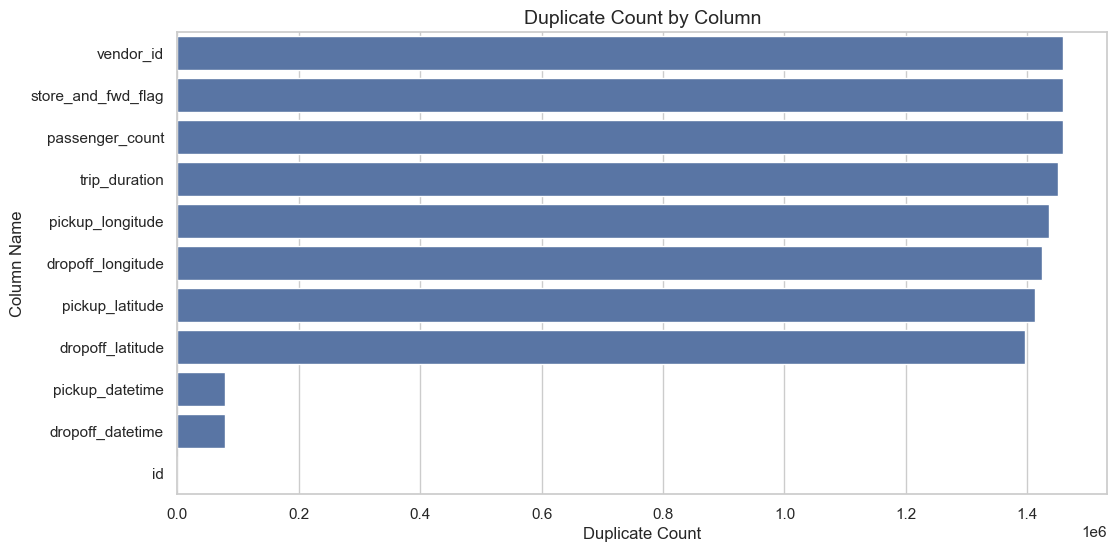

In [8]:

dup_summary = summary_df[["column_name", "duplicate_count", "duplicate_percentage"]].copy()
dup_summary = dup_summary.sort_values(by="duplicate_count", ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=dup_summary,
    x="duplicate_count",
    y="column_name"
)

plt.title("Duplicate Count by Column")
plt.xlabel("Duplicate Count")
plt.ylabel("Column Name")
plt.show()

# 2. 🧩 Feature Extraction & Feature Type Classification

In this section, we will identify different types of features from the NYC Taxi Trip dataset before detailed EDA.

---

## 🔢 Numeric Features

### 📏 Continuous Features
- `pickup_longitude`
- `pickup_latitude`
- `dropoff_longitude`
- `dropoff_latitude`
- `trip_duration` 🎯 Target variable

### 👥 Count / Discrete Numeric Features
- `passenger_count`

### 🔢 Ordinal Numeric Features
- No direct ordinal numeric feature found in this dataset

### ⏰ Temporal Numeric Features  
Features that can be extracted from datetime columns:

From `pickup_datetime`:
- `pickup_hour`
- `pickup_day`
- `pickup_month`
- `pickup_dayofweek`
- `pickup_weekend`
- `pickup_minute`

From `dropoff_datetime`:
- `dropoff_hour`
- `dropoff_day`
- `dropoff_month`
- `dropoff_dayofweek`

---

## 🏷️ Categorical Features

### 🧾 Nominal Categorical Features
- `vendor_id`

### 🔁 Binary Categorical Features
- `store_and_fwd_flag`

### 📊 Ordinal Categorical Features
- No direct ordinal categorical feature found in this dataset

---

## 🆔 Identifier Feature

### Unique ID
- `id`

This column is mainly used for identifying each trip and is usually not used directly for analysis or modeling.

---

## 🎯 Target Feature

### Prediction Target
- `trip_duration`

This is the main target variable for the NYC Taxi Trip Duration prediction project.

# 3. 🎯 Target Variable Analysis — Trip Duration

In this section, we will analyze the target variable `trip_duration`, which represents the total duration of each taxi trip.  
We will check its basic statistics, distribution pattern, skewness, outliers, and possible transformation needs.  
This step is important because the target variable directly affects model learning and prediction performance.